## DAY_19_EDA Workflow & Visualization — Ames Housing

Part A — run the first-30-minutes checklist

TASK_01_Understand the data before any charts

Dataset loaded successfully!

Dataset Shape:
(1460, 11)

The dataset has 1460 rows and 11 columns.

First 5 Rows:


,Id,Neighborhood,OverallQual,GrLivArea,YearBuilt,Bedrooms,FullBath,GarageCars,LotArea,SalePrice,LotFrontage
0,1,BrkSide,4,1726,1963,4,1,2,9055,188300,64.0
1,2,CollgCr,6,2292,1921,5,2,2,12134,267200,42.0
2,3,BrkSide,5,2063,2001,3,2,2,9699,254400,77.0
3,4,Edwards,6,2379,1952,4,1,3,16192,230600,NaN
4,5,NoRidge,8,2339,1996,4,2,2,10937,390200,74.0



Dataset information : 
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            1460 non-null   int64  
 1   Neighborhood  1460 non-null   str    
 2   OverallQual   1460 non-null   int64  
 3   GrLivArea     1460 non-null   int64  
 4   YearBuilt     1460 non-null   int64  
 5   Bedrooms      1460 non-null   int64  
 6   FullBath      1460 non-null   int64  
 7   GarageCars    1460 non-null   int64  
 8   LotArea       1460 non-null   int64  
 9   SalePrice     1460 non-null   int64  
 10  LotFrontage   1212 non-null   float64
dtypes: float64(1), int64(9), str(1)
memory usage: 125.6 KB
Summary Statistics : 


,Id,OverallQual,GrLivArea,YearBuilt,Bedrooms,FullBath,GarageCars,LotArea,SalePrice,LotFrontage
count,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1212.0
mean,730.0,5.0,1870.0,1961.0,4.0,2.0,2.0,12713.0,237645.0,70.0
std,422.0,2.0,462.0,31.0,1.0,1.0,1.0,4514.0,65093.0,22.0
min,1.0,1.0,656.0,1900.0,1.0,1.0,0.0,1500.0,92100.0,21.0
25%,366.0,4.0,1559.0,1935.0,3.0,2.0,1.0,10292.0,187550.0,55.0
50%,730.0,5.0,1846.0,1961.0,4.0,2.0,2.0,12694.0,230600.0,69.0
75%,1095.0,6.0,2163.0,1988.0,4.0,3.0,2.0,15152.0,276750.0,85.0
max,1460.0,10.0,4600.0,2010.0,6.0,4.0,4.0,115000.0,595000.0,138.0



Neighborhood Counts : 
Neighborhood
OldTown    182
CollgCr    166
BrkSide    148
Edwards    146
Gilbert    140
NWAmes     125
Somerst    117
BrDale      77
IDOTRR      67
Timber      61
MeadowV     60
NridgHt     51
NoRidge     49
StoneBr     44
Veenker     27
Name: count, dtype: int64

Missing Values : 
LotFrontage    248
dtype: int64

Missing Value Percentage : 
LotFrontage    16.99
dtype: float64


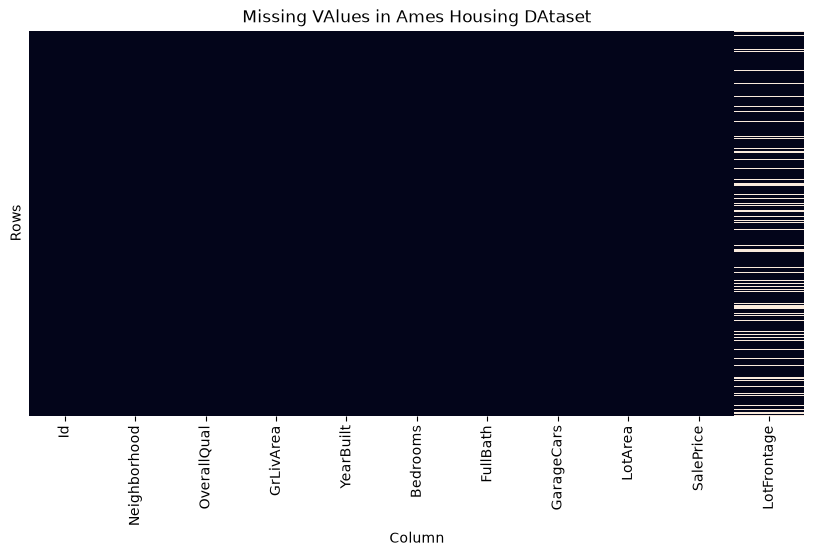

TAkeway : Missing value occur only in LotFrontage.

SalePrice Summary:
Minimum SalePrice : $92,100
Maximum SalePrice : $595,000
Mean SalePrice    : $237,645
Median SalePrice  : $230,600

SalePrice Outlier Check:
75th percentile : $276,750
Maximum         : $595,000

Takeaway: The maximum SalePrice is considerably higher than the 75th percentile, so high-priced houses should be investigated as possible outliers.

FINAL EDA NOTES
1. Dataset size: 1460 rows and 11 columns.
2. Missing data: LotFrontage has 248 missing values (16.99%).
3. SalePrice range: $92,100 to $595,000.
4. Typical SalePrice: the median is $230,600, while the mean is $237,645.
5. Suspicious value: SalePrice has a maximum of $595,000, which is well above its 75th percentile of $276,750.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 


# ------------------------------------------------------------
# 1. LOAD THE DATA
# ------------------------------------------------------------

# Load the Ames Housing dataset
df = pd.read_csv("ames_housing.csv")

print("Dataset loaded successfully!")
print()

# ------------------------------------------------------------
# 2. CHECK THE SHAPE
# ------------------------------------------------------------

# .shape returns (number of rows, number of columns)
print("Dataset Shape:")
print(df.shape)

print(f"\nThe dataset has {df.shape[0]} rows and {df.shape[1]} columns.")


# ------------------------------------------------------------
# 3. VIEW THE FIRST 5 ROWS
# ------------------------------------------------------------

# head() helps us understand the structure and values
print("\nFirst 5 Rows:")
display(df.head())

# ------------------------------------------------------------
# 4. CHECK DATA TYPES AND NON-NULL VALUES
# ------------------------------------------------------------

# info() shows column names, data types, and missing values
print("\nDataset information : ")
df.info()

# ------------------------------------------------------------
# 5. SUMMARY STATISTICS
# ------------------------------------------------------------

# describe() gives statistical information for numerical columns
print("Summary Statistics : ")
display(df.describe().round())

# ------------------------------------------------------------
# 6. CHECK CATEGORICAL VALUES
# ------------------------------------------------------------

# Neighborhood is a categorical column.
# value_counts() shows how many houses belong to each neighborhood.
print("\nNeighborhood Counts : ")
print(df["Neighborhood"].value_counts())


# ------------------------------------------------------------
# 7. CHECK MISSING VALUES
# ------------------------------------------------------------

# Count missing values in every column
missing_count = df.isnull().sum()

# Keep only columns that contain missing values
missing_count = missing_count[missing_count > 0]

print("\nMissing Values : ")
print(missing_count)


# ------------------------------------------------------------
# 8. CALCULATE MISSING-VALUE FRACTION
# ------------------------------------------------------------

# Calculate percentage of missing values in each column
missing_percent = (df.isnull().mean() * 100).round(2)

# Keep only columns with missing values
missing_percent = missing_percent[missing_percent > 0 ]

print("\nMissing Value Percentage : ")
print(missing_percent)


# ------------------------------------------------------------
# 9. MISSING-VALUE MAP
# ------------------------------------------------------------

# Visualize where missing values occur
plt.figure(figsize=(10, 5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing VAlues in Ames Housing DAtaset")
plt.xlabel("Column")
plt.ylabel("Rows")
plt.show()

print("TAkeway : Missing value occur only in LotFrontage.")

# ------------------------------------------------------------
# 10. SALEPRICE SUMMARY
# ------------------------------------------------------------

# SalePrice is our target variable.
# Check its minimum, maximum, mean and median.
sale_min = df["SalePrice"].min()
sale_max = df["SalePrice"].max()
sale_mean = df["SalePrice"].mean()
sale_median = df["SalePrice"].median()

print("\nSalePrice Summary:")
print(f"Minimum SalePrice : ${sale_min:,.0f}")
print(f"Maximum SalePrice : ${sale_max:,.0f}")
print(f"Mean SalePrice    : ${sale_mean:,.0f}")
print(f"Median SalePrice  : ${sale_median:,.0f}")


# ------------------------------------------------------------
# 11. CHECK FOR SUSPICIOUS VALUES
# ------------------------------------------------------------

# Compare the 75th percentile with the maximum.
# A very large difference may indicate possible outliers.
sale_stats = df["SalePrice"].describe()

print("\nSalePrice Outlier Check:")
print(f"75th percentile : ${sale_stats['75%']:,.0f}")
print(f"Maximum         : ${sale_stats['max']:,.0f}")

print(
    "\nTakeaway: The maximum SalePrice is considerably higher "
    "than the 75th percentile, so high-priced houses should "
    "be investigated as possible outliers."
)

# ------------------------------------------------------------
# 12. FINAL EDA NOTES
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL EDA NOTES")
print("=" * 60)

print(f"1. Dataset size: {df.shape[0]} rows and {df.shape[1]} columns.")

print(
    f"2. Missing data: LotFrontage has {df['LotFrontage'].isnull().sum()} "
    f"missing values ({df['LotFrontage'].isnull().mean() * 100:.2f}%)."
)

print(
    f"3. SalePrice range: ${sale_min:,.0f} to ${sale_max:,.0f}."
)

print(
    f"4. Typical SalePrice: the median is ${sale_median:,.0f}, "
    f"while the mean is ${sale_mean:,.0f}."
)

print(
    "5. Suspicious value: SalePrice has a maximum of "
    f"${sale_max:,.0f}, which is well above its 75th percentile "
    f"of ${sale_stats['75%']:,.0f}."
)

### Look It Up — Short Answers

1. **Why run the checklist every time?**
   It helps catch missing values, wrong data types, unusual values, and data-quality problems before analysis.

2. **Danger of jumping straight to modeling:**
   The model may learn from bad or incomplete data, leading to misleading results and poor predictions.

3. **Mean much higher than median:**
   It usually indicates a **right-skewed distribution**, often caused by a few unusually large values or outliers.

### Done When

* **Shape:** 1,460 rows × 11 columns.
* **Missing data:** `LotFrontage` has 248 missing values (16.99%).
* **Suspicious value:** `SalePrice` has a high maximum ($595,000) compared with its 75th percentile ($276,750), suggesting possible high-value outliers.


Part B — 10+ visualizations telling a story (the deliverable)

TASK 02 Univariate — each variable's own shape

<Axes: xlabel='SalePrice', ylabel='Count'>

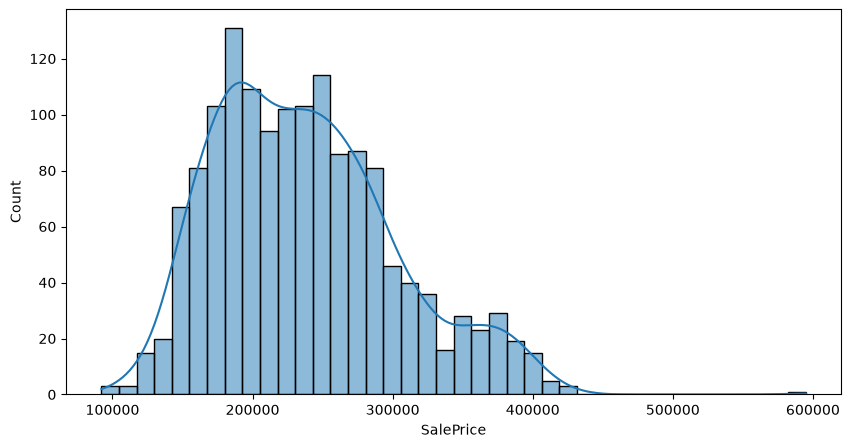

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Ames Housing dataset
df = pd.read_csv("ames_housing.csv")

# ------------------------------------------------------------
# 1. SalePrice Distribution
# ------------------------------------------------------------

# Histogram with KDE to understand the distribution of SalePrice
plt.figure(figsize=(10, 5))

sns.histplot(
    df["SalePrice"],
    bins=40,
    kde=True
)

plt.title("Distribution of SalePrice")
plt.xlabel("Sale Price ($)")
plt.ylabel("Number of Houses")
plt.show()

# Takeaway:
# SalePrice is right-skewed, with most houses at lower prices
# and a smaller number of very expensive houses.


# ------------------------------------------------------------
# 2. GrLivArea Distribution
# ------------------------------------------------------------

# GrLivArea represents above-ground living area in square feet
plt.figure(figsize=(10, 5))

sns.histplot(
    df["GrLivArea"],
    bins=40,
    kde=True
)

plt.title("Distribution of Above-Ground Living Area")
plt.xlabel("Above-Ground Living Area (sq ft)")
plt.ylabel("NUmber of Houses")
plt.show()

# Takeaway:
# GrLivArea is mostly concentrated at smaller-to-medium sizes,
# with a right tail and a few unusually large houses.


# ------------------------------------------------------------
# 3. YearBuilt Distribution
# ------------------------------------------------------------

# YearBuilt shows when each house was originally constructed
plt.figure(figsize=(10, 5))

sns.histplot(
    df["YearBuilt"],
    bins=40,
    kde=True
)

plt.title("Distribution of Year Built ")
plt.xlabel("Year Built")
plt.ylabel("Number Of Houses")
plt.show()

# Takeaway:
# YearBuilt is concentrated more heavily in recent decades,
# with fewer houses built in the older years.


# ------------------------------------------------------------
# 4. OverallQual Count
# ------------------------------------------------------------

# OverallQual is a discrete quality rating from 1 to 10

plt.figure(figsize=(10, 5))

sns.countplot(
    x="OverallQual",
    date=df
)

plt.title("Number of Houses by Overall Quality")
plt.xlabel("Overall Quality Rating")
plt.ylabel("Number of Houses")
plt.show()

# Takeaway:
# OverallQual is concentrated around average-to-good quality
# ratings, while very low and very high ratings are less common.


### Look It Up — Short Answers

1. **Why does SalePrice’s shape matter before modeling?**
   Its distribution can reveal **skewness and outliers**, which may affect model assumptions and performance.

2. **Histogram vs. boxplot:**
   Use a **histogram** to see the detailed distribution, such as peaks, gaps, and skewness. Use a **boxplot** to quickly compare groups and identify outliers. 

3. **What does a long right tail mean for house prices?**
   Most houses are at lower or moderate prices, while **a smaller number of houses have much higher prices**, creating the long upper tail. 

**Done when:** At least **3 univariate charts** are created, each has a **title and labelled axes**, and each includes a **one-line takeaway**.



TASK 03 Bivariate — what drives price?

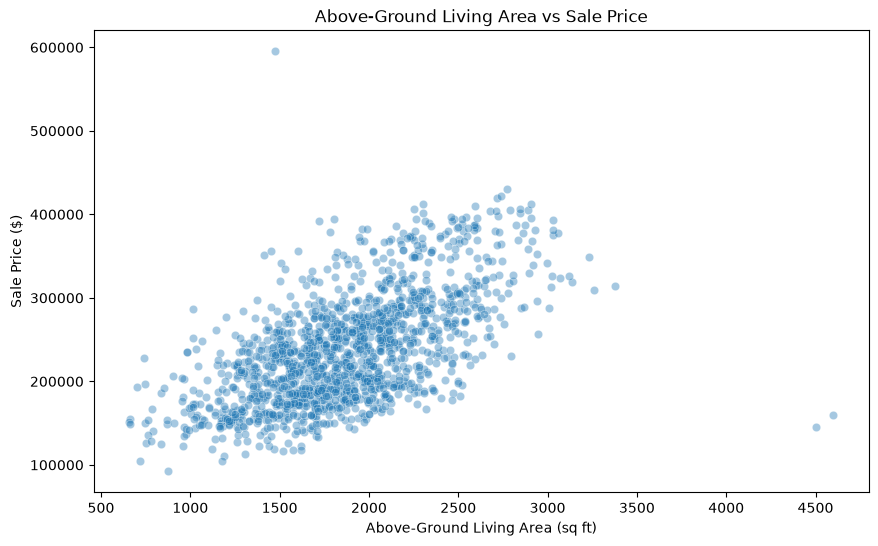

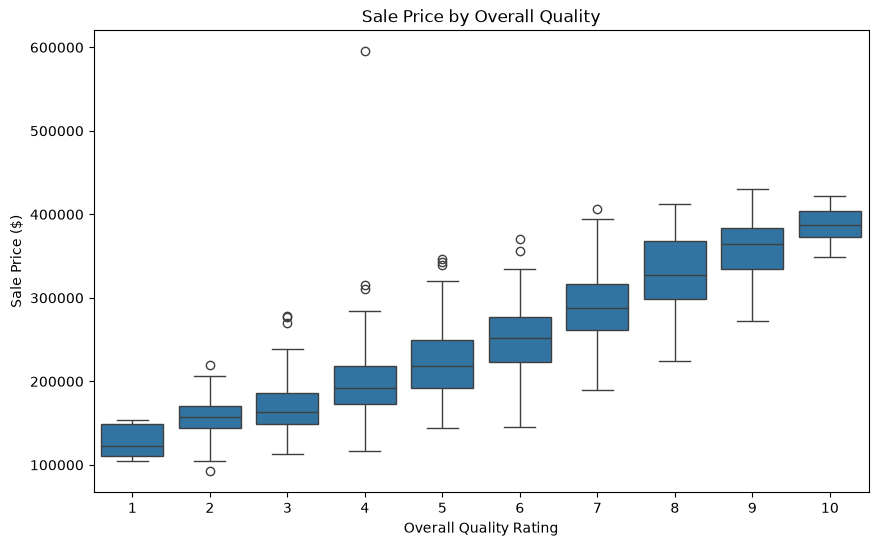

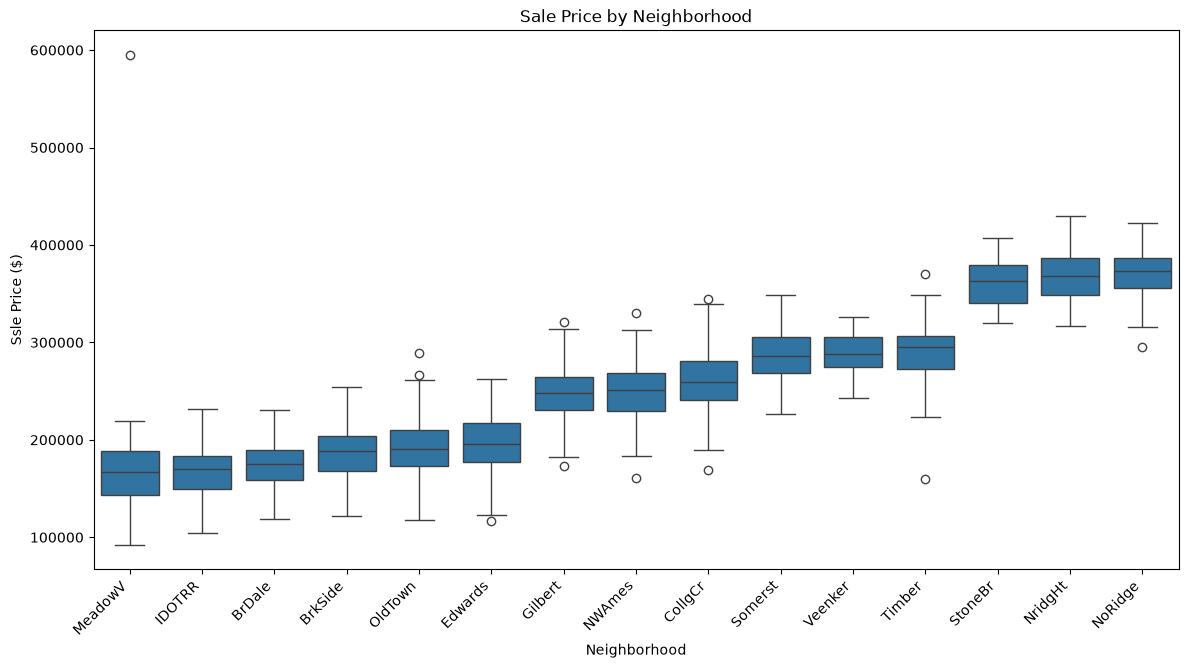

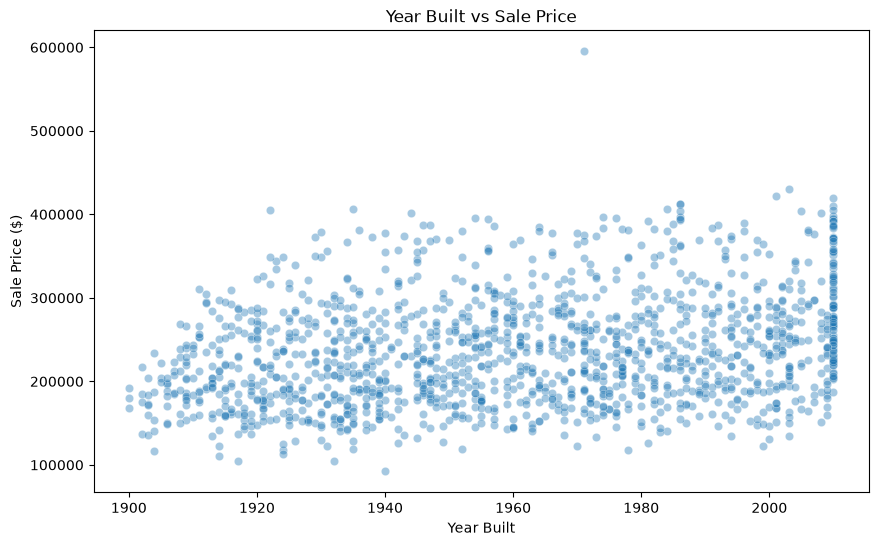

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("ames_housing.csv")


# ------------------------------------------------------------
# 1. GrLivArea vs SalePrice — Scatter Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice",
    alpha=0.4
)


plt.title("Above-Ground Living Area vs Sale Price")
plt.xlabel("Above-Ground Living Area (sq ft)")
plt.ylabel("Sale Price ($)")
plt.show()

# Takeaway:
# SalePrice generally increases as GrLivArea increases,
# but a few large houses have unusually low prices.

# ------------------------------------------------------------
# 2. SalePrice by OverallQual — Boxplot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="OverallQual",
    y="SalePrice"
)

plt.title("Sale Price by Overall Quality")
plt.xlabel("Overall Quality Rating")
plt.ylabel("Sale Price ($)")
plt.show()

# Takeaway:
# SalePrice generally rises as OverallQual increases,
# showing a strong relationship between quality and price.


# ------------------------------------------------------------
# 3. SalePrice by Neighborhood — Sorted Boxplot
# ------------------------------------------------------------

# Calculate median SalePrice for each neighborhood
# and sort neighborhoods from lowest to highest median price.

order = (
    df.groupby("Neighborhood")["SalePrice"]
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df,
    x="Neighborhood",
    y="SalePrice",
    order=order
)

plt.title("Sale Price by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Ssle Price ($)")

# Rotate labels so all neighborhood names are readable
plt.xticks(rotation=45, ha="right")
plt.show()

# Takeaway:
# SalePrice varies substantially by neighborhood,
# with some neighborhoods having much higher typical prices.


# ------------------------------------------------------------
# 4. YearBuilt vs SalePrice — Scatter Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="YearBuilt",
    y="SalePrice",
    alpha=0.4
)

plt.title("Year Built vs Sale Price")
plt.xlabel("Year Built")
plt.ylabel("Sale Price ($)")
plt.show()

# Takeaway:
# Newer houses generally have higher SalePrice, although
# the relationship is weaker and more variable than quality.

### Look It Up — Short Answers

1. **Why sort neighborhoods before plotting?**
   Sorting by median price turns the boxplot into a **clear ranking**, making differences between neighborhoods easier to compare. 

2. **Scatter plot vs. boxplot:**
   Use a **scatter plot** for relationships between two numeric variables. Use a **boxplot** to compare a numeric variable across categories and see spread/outliers. 

3. **Stronger driver so far:**
   Based on the Ames charts, **OverallQual (quality)** appears to have the strongest relationship with SalePrice, while size and neighborhood also show clear relationships. This is a visual EDA observation, not proof of causation.

**Done when:** At least **3 bivariate charts** are created, including a **sorted neighborhood boxplot**, with a clear takeaway for each.




TASK 04 Multivariate — the whole picture

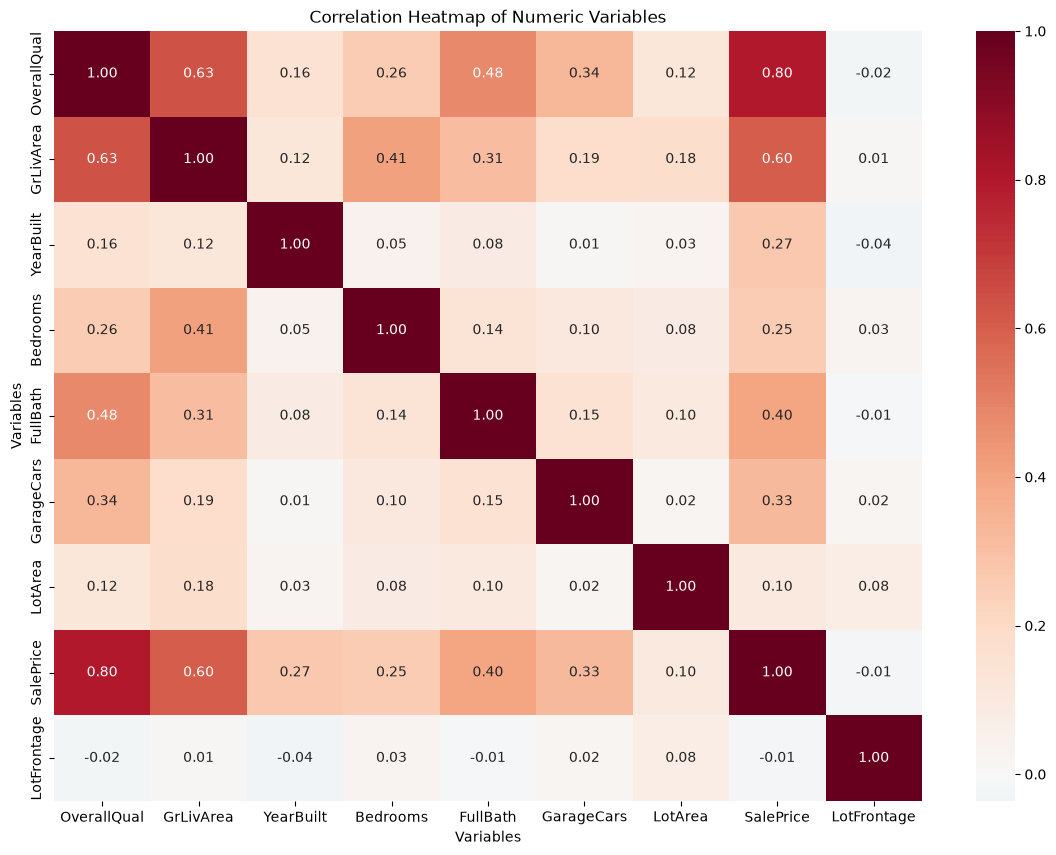

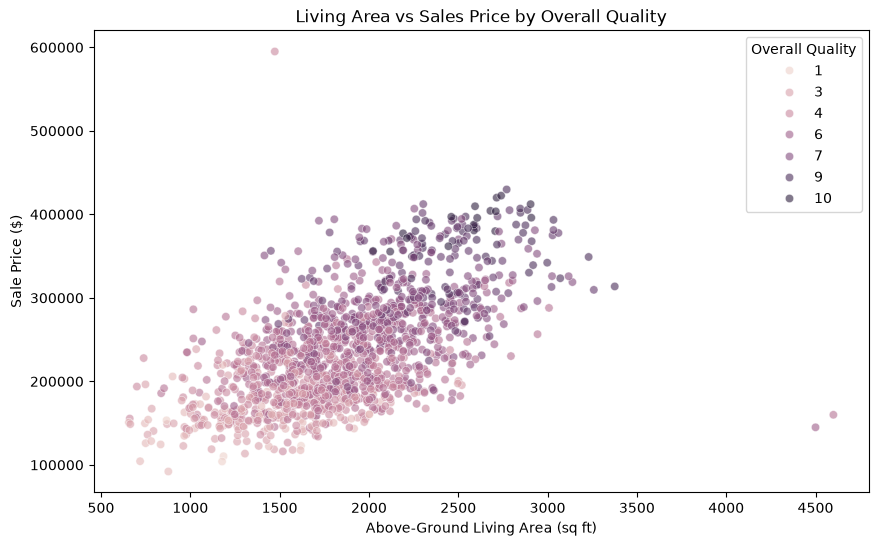

In [ ]:
# ============================================================
# TASK 04 — Multivariate Analysis
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load dataset
df = pd.read_csv("ames_housing.csv")


# ------------------------------------------------------------
# 1. Correlation Heatmap
# ------------------------------------------------------------

# Select numeric columns and remove Id because it is only an identifier
corr = df.select_dtypes("number").drop(columns=["Id"]).corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0
)

plt.title("Correlation Heatmap of Numeric Variables")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.show()

# Takeaway:
# OverallQual has the strongest correlation with SalePrice.


# ------------------------------------------------------------
# 2. Scatter Plot with Third Variable as Colour
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice",
    hue="OverallQual",
    alpha=0.6
)

plt.title("Living Area vs Sales Price by Overall Quality")
plt.xlabel("Above-Ground Living Area (sq ft)")
plt.ylabel("Sale Price ($)")
plt.legend(title="Overall Quality")
plt.show()

# Takeaway:
# Larger homes generally cost more, and higher-quality homes
# tend to occupy the higher-price part of the relationship.


# ------------------------------------------------------------
# 3. Interactive Plotly Scatter Plot
# ------------------------------------------------------------

fig = px.scatter(
    df,
    x="GrLivArea",
    y="SalePrice",
    color="OverallQual",
    hover_data=["Neighborhood", "YearBuilt"],
    title="Interactive: Living Area vs Sale Price by Quality",
    labels={
        "GrLivArea": "Above-Ground Living Area (sq ft)",
        "SalePrice": "Sale Price ($)",
        "OverallQual": "Overall Quality"
    }
) 

fig.show()

# Takeaway:
# The interactive chart allows individual houses to be explored
# by hovering over points to see neighborhood and year built.

### TASK 04 — Short Research Answers

**1. Why is a correlation heatmap often very useful in EDA?**
It gives a quick overview of relationships between many numeric variables at once and helps identify strong positive or negative correlations. 

**2. When is an interactive chart worth the extra effort?**
When the dataset has many points or details, interactivity lets users hover, zoom, filter, and explore individual observations more easily than a static chart.

**3. Does correlation prove causation?**
**No.** Correlation only shows that variables move together; a third variable, reverse causation, or coincidence may explain the relationship. 

**Top 3 drivers of SalePrice in this dataset:**

1. **OverallQual** — 0.80
2. **GrLivArea** — 0.60
3. **FullBath** — 0.40

*These are the strongest correlations with SalePrice, not proof that they cause higher prices.*



Part C — outliers and the wider toolkit

TASK 05 Hunt the outliers

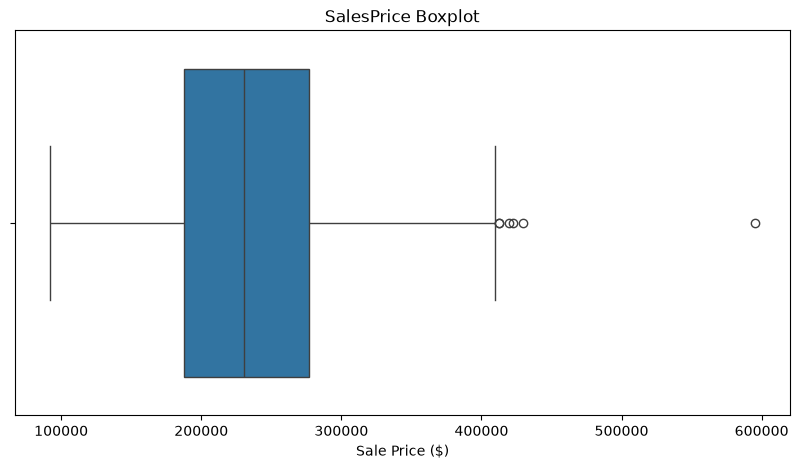

Takeway : Points beyond the wiskers are potential Saleprice Outliers.

--- IQR Outlier Detection ---
Q1 : $187,550
Q2 : $276,750
IQR : $89,200
Lower Limit : $53,750
Upper Limit : $410,550
Number of SalePrice Outliers : 6

SalePrice Outliers:
        Id  SalePrice  GrLivArea Neighborhood  OverallQual
1152  1153     412200       2905      NoRidge           10
844    845     412300       2304      NoRidge            8
1432  1433     420000       2715      NridgHt           10
1443  1444     422400       2740      NoRidge           10
810    811     429800       2771      NridgHt            9
319    320     595000       1473      MeadowV            4

Takeaway: Houses priced above the upper IQR limit are flagged as potential price outliers.

--- Large Houses with Low Price ---
Number Of Houses : 2
        Id  GrLivArea  SalePrice Neighborhood  OverallQual
857    858       4500     145000       IDOTRR            6
1015  1016       4600     160000       Timber            5

Takeaway: These h

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Ames Housing dataset
df = pd.read_csv("ames_housing.csv")


# ------------------------------------------------------------
# 1. Boxplot of SalePrice
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
sns.boxplot(x=df["SalePrice"])
plt.title("SalesPrice Boxplot")
plt.xlabel("Sale Price ($)")
plt.show()

print("Takeway : Points beyond the wiskers are potential Saleprice Outliers.")

# ------------------------------------------------------------
# 2. Detect SalePrice outliers using the IQR method
# ------------------------------------------------------------

# Calculate Q1, Q3 and IQR
q1, q3 = df["SalePrice"].quantile([0.25, 0.75])
iqr = q3 - q1

# Calculate the IQR boundaries
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

# Find price outliers
price_outliers = df[
    (df["SalePrice"] < lower_limit) |
    (df["SalePrice"] > upper_limit)
]


print("\n--- IQR Outlier Detection ---")
print(f"Q1 : ${q1:,.0f}")
print(f"Q2 : ${q3:,.0f}")
print(f"IQR : ${iqr:,.0f}")
print(f"Lower Limit : ${lower_limit:,.0f}")
print(f"Upper Limit : ${upper_limit:,.0f}")
print(f"Number of SalePrice Outliers : {len(price_outliers)}")


print("\nSalePrice Outliers:")
print(
    price_outliers[
        ["Id", "SalePrice", "GrLivArea", "Neighborhood", "OverallQual"]
    ].sort_values("SalePrice")
)

print(
    "\nTakeaway: Houses priced above the upper IQR limit are "
    "flagged as potential price outliers."
)


# ------------------------------------------------------------
# 3. Find houses with very large living area but low price
# ------------------------------------------------------------

large_low_price = df[
    (df["GrLivArea"] > 4000) & 
    (df["SalePrice"] < 200000)
]

print("\n--- Large Houses with Low Price ---")
print(f"Number Of Houses : {len(large_low_price)}")

print(
    large_low_price[
        ["Id", "GrLivArea", "SalePrice", "Neighborhood", "OverallQual"]
    ]
)

print(
    "\nTakeaway: These houses have unusually large living areas "
    "but relatively low sale prices and should be investigated."
)

# ------------------------------------------------------------
# 4. Outlier interpretation and recommended action
# ------------------------------------------------------------

print("\n--- Outliers Interpretation ---")

print(
    "SalePrice outliers: Likely genuine expensive properties; "
    "keep them unless the original records show an error."
)

for _, row in large_low_price.iterrows():
    print(
        f"ID {int(row['Id'])}: {int(row['GrLivArea']):,} sq ft, "
        f"${row['SalePrice']:,.0f} — unusual size-price relationship; "
        f"check the original record before removing."
    )

print(
    "\nFinal takeaway: Outliers should not be deleted automatically; "
    "first determine whether they represent genuine rare houses or data errors."
)

### Short & Meaningful Answers

1. **Why can a single outlier badly distort a model?**  
   A single extreme value can strongly affect the mean, correlation, and regression line, causing the model to learn a relationship that does not represent most of the data. :chatgpt-content-reference{index="0"}

2. **Should you always delete outliers? When might you keep them?**  
   **No.** Keep an outlier if it is a genuine observation, such as a real luxury house. Remove it only when there is evidence of a data-entry, measurement, or other data-quality error. :chatgpt-content-reference{index="1"}

3. **What's the difference between an outlier in one variable and one that breaks a relationship?**  
   - **Univariate outlier:** unusual in one variable, e.g., an extremely high `SalePrice`.
   - **Relationship outlier:** unusual compared with the relationship between variables, e.g., a very large house with an unexpectedly low price. Such points can have high influence on a regression model. :chatgpt-content-reference{index="2"}



TASK 06 Try plotnine (ggplot grammar)

In [ ]:
import pandas as pd
from plotnine import ggplot, aes, geom_point, labs, theme_minimal

df = pd.read_csv("ames_housing.csv")

# ------------------------------------------------------------
# 3. Recreate an earlier chart using plotnine
#    GrLivArea vs SalePrice, coloured by OverallQual
# ------------------------------------------------------------

plot = (
    ggplot(
        df,
        aes(
            x = "GrLivArea",
            y = "SalePrice",
            color = "OverallQual"
        )
    )
    + geom_point(alpha = 0.4)
    + labs(
        title = "Living Area vs Sale Price "
        x = "Living Area (sq ft)",
        y = "Sale Price ($)",
        color = "Overall Quality"
    )
    + theme_minimal()
)

plot




Comparison: plotnine vs seaborn

-> Plotnine felt more structured because it builds charts 
-> step-by-step using data, aesthetics, and layers.

-> Seaborn felt more natural to me for quick Python plots, 
-> while plotnine is useful when I want a clear grammar-of-graphics style.

### Short & Meaningful Answers

1. **What does “Grammar of Graphics” mean?**  
   It means building a chart from separate, reusable parts such as **data → aesthetics → layers/geoms → scales → theme**. This makes complex charts easier to construct and modify step by step. :chatgpt-content-reference{index="0"}

2. **Why do some people prefer the ggplot style?**  
   They like it because the layered structure is **consistent, flexible, and easy to extend**. Instead of creating a completely different command for every chart, you add or modify layers. :chatgpt-content-reference{index="1"}

3. **When would you pick Seaborn, Plotnine, or Plotly?**
   - **Seaborn:** Quick and attractive **statistical charts** in Python.
   - **Plotnine:** When you prefer the **ggplot/Grammar-of-Graphics layered approach**.
   - **Plotly:** When you need **interactive charts**, such as hover, zoom, filtering, or web-based visualizations. :chatgpt-content-reference{index="2"}

### Comparison with Seaborn

**Plotnine:** More structured and layer-based, so it feels natural when building a chart step by step.  
**Seaborn:** Feels simpler for quickly creating common statistical plots in Python.

